# Cross-sectional determinants of GDP per capita growth, 2024

Python replication of `growth_analysis.do`. The specification is

$$\text{growth24}_i = \beta_0 + \beta_1 \ln(\text{gdppc23}_i) + \beta_2 \text{gcf23}_i + \beta_3 \text{highinc}_i + \varepsilon_i$$

| Symbol | Variable | Definition |
|---|---|---|
| $Y$ | `growth24` | Real GDP per capita growth in 2024, % (constant 2015 US$) |
| $X_1$ | `lngdppc23` | Log real GDP per capita, 2023 — conditional convergence term |
| $X_2$ | `gcf23` | Gross capital formation, 2023, % of GDP |
| $X_3$ | `highinc` | 1 if a World Bank high-income economy, else 0 |

Source: World Bank World Development Indicators, pulled via the public API in
`code/fetch_wdi.py` and cleaned in `code/build_panel.py`. The sample is every
economy with complete data on all four variables.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor

ROOT = Path.cwd().parent if Path.cwd().name == "code" else Path.cwd()
pd.set_option("display.width", 110)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

Y, XS = "growth24", ["lngdppc23", "gcf23", "highinc"]
FORMULA = f"{Y} ~ " + " + ".join(XS)

df = pd.read_csv(ROOT / "data" / "growth_panel.csv")
print(f"{len(df)} economies, {df['highinc'].sum()} of them high-income")
df.head()

171 economies, 61 of them high-income


,iso3,country,region,income_group,growth24,lngdppc23,gcf23,highinc,infl23,unemp23,trade23,popgrow23,gdppc23,gdppc24
0,ABW,Aruba,Latin America & Caribbean,High income,6.181751,10.372337,18.380863,1,NaN,NaN,153.719158,0.045652,31963.076451,33938.954177
1,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,-0.975915,5.935070,15.292482,0,-4.644709,14.008,66.999578,2.135594,378.066303,374.376696
2,AGO,Angola,Sub-Saharan Africa,Lower middle income,1.805850,7.918975,12.438866,0,13.644102,14.051,53.607013,3.080655,2748.951970,2798.593928
3,ALB,Albania,Europe & Central Asia,Upper middle income,5.557293,8.733020,23.439286,0,4.758346,10.669,82.352493,-1.644108,6204.435256,6549.233874
4,ARE,United Arab Emirates,"Middle East, North Africa, Afghanistan & Pakistan",High income,-0.766014,10.643675,26.638667,1,1.626708,2.151,199.044950,3.977171,41926.577350,41605.413871


## Section A — Descriptive statistics

In [2]:
desc = df[[Y] + XS].describe().T[["count", "mean", "std", "min", "50%", "max"]]
desc.columns = ["N", "Mean", "SD", "Min", "Median", "Max"]
desc["Skew"] = df[[Y] + XS].skew()
desc["Kurtosis"] = df[[Y] + XS].kurtosis() + 3
desc.round(3)

,N,Mean,SD,Min,Median,Max,Skew,Kurtosis
growth24,171.0,1.819,3.729,-24.657,2.145,12.209,-2.690,19.773
lngdppc23,171.0,8.794,1.429,5.935,8.729,11.646,0.003,2.061
gcf23,171.0,23.404,7.918,-3.735,22.941,45.266,-0.025,4.255
highinc,171.0,0.357,0.480,0.000,0.000,1.000,0.603,1.345


Growth is heavily left-skewed: a handful of economies contracted sharply in
2024, which is what the kurtosis figure is picking up. That matters for the
normality diagnostic in Section B and motivates the trimmed subsample in
Section C.

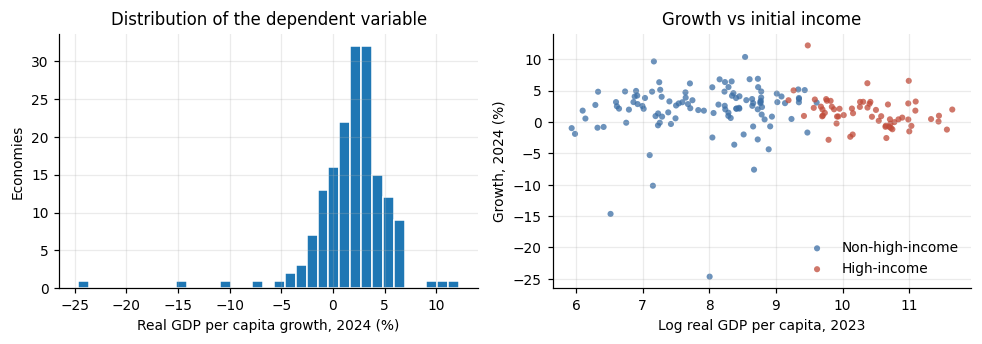

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].hist(df[Y], bins=35, edgecolor="white")
axes[0].set(xlabel="Real GDP per capita growth, 2024 (%)", ylabel="Economies",
            title="Distribution of the dependent variable")
for flag, label, colour in [(0, "Non-high-income", "#3b6ea5"),
                            (1, "High-income", "#c04a38")]:
    sub = df[df["highinc"] == flag]
    axes[1].scatter(sub["lngdppc23"], sub[Y], s=16, alpha=0.75, label=label,
                    color=colour, edgecolor="none")
axes[1].set(xlabel="Log real GDP per capita, 2023",
            ylabel="Growth, 2024 (%)", title="Growth vs initial income")
axes[1].legend(frameon=False)
fig.tight_layout()

## Section A — OLS estimation

In [4]:
ols = smf.ols(FORMULA, data=df).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:               growth24   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     5.835
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           0.000816
Time:                        16:32:44   Log-Likelihood:                -458.69
No. Observations:                 171   AIC:                             925.4
Df Residuals:                     167   BIC:                             937.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.7858      2.781     -1.002      0.3

Reading the coefficients: the investment share is the only regressor that
clears conventional significance levels, and the convergence term is both small
and imprecisely estimated. A one-year cross-section is a noisy setting in which
to look for convergence, which typically shows up over decades rather than over
a single year.

## Section B — Diagnostic tests

Three assumption violations are tested: homoskedasticity (Breusch-Pagan and
White), no perfect multicollinearity (variance inflation factors), and correct
functional form (Ramsey RESET). Normality of the errors is reported as
supporting evidence via Jarque-Bera.

In [5]:
def white_test(res):
    """White LM test on a full-rank auxiliary design.

    Feeding every square and cross product into the auxiliary regression makes
    it rank deficient when a dummy is present, because highinc**2 == highinc.
    Duplicates are removed first, then any column that adds no rank, so the
    degrees of freedom are right.
    """
    exog = pd.DataFrame(res.model.exog, columns=res.model.exog_names)
    regs = [c for c in exog.columns if c != "Intercept"]

    aux = pd.DataFrame({"Intercept": 1.0}, index=exog.index)
    for i, a in enumerate(regs):
        aux[a] = exog[a]
        for b in regs[i:]:
            aux[f"{a}^2" if a == b else f"{a}:{b}"] = exog[a] * exog[b]
    aux = aux.T.drop_duplicates().T

    keep = []
    for col in aux.columns:
        if np.linalg.matrix_rank(aux[keep + [col]].to_numpy()) == len(keep) + 1:
            keep.append(col)
    aux = aux[keep]

    e2 = res.resid.to_numpy() ** 2
    lm = sm.OLS(e2, aux.to_numpy()).fit().rsquared * len(e2)
    dof = aux.shape[1] - 1
    return lm, float(st.chi2.sf(lm, dof)), dof


bp_lm, bp_p, _, _ = het_breuschpagan(ols.resid, ols.model.exog)
w_lm, w_p, w_dof = white_test(ols)
reset = linear_reset(ols, power=2, use_f=True)
jb, jb_p, _, _ = sm.stats.stattools.jarque_bera(ols.resid)

pd.DataFrame(
    [
        ("Breusch-Pagan (LM)", bp_lm, bp_p, "Homoskedastic errors"),
        (f"White (LM, {w_dof} df)", w_lm, w_p, "Homoskedastic errors"),
        ("Ramsey RESET (F)", reset.fvalue, reset.pvalue, "Correct functional form"),
        ("Jarque-Bera", jb, jb_p, "Normally distributed errors"),
    ],
    columns=["Test", "Statistic", "p-value", "Null hypothesis"],
).round(4)

,Test,Statistic,p-value,Null hypothesis
0,Breusch-Pagan (LM),1.7275,0.6308,Homoskedastic errors
1,"White (LM, 8 df)",4.2251,0.8363,Homoskedastic errors
2,Ramsey RESET (F),0.0683,0.7942,Correct functional form
3,Jarque-Bera,2966.8729,0.0000,Normally distributed errors


In [6]:
X = sm.add_constant(df[XS])
pd.DataFrame({"Variable": X.columns,
              "VIF": [variance_inflation_factor(X.values, i)
                      for i in range(X.shape[1])]}).round(3)

,Variable,VIF
0,const,1.000
1,lngdppc23,3.032
2,gcf23,1.001
3,highinc,3.033


The two heteroskedasticity tests do not reject, RESET does not reject, and the
VIFs sit far below the usual threshold of 10 — the correlation between log
income and the high-income dummy is by construction, but not severe enough to
destabilise the estimates. Jarque-Bera rejects normality decisively, driven by
the same left tail visible in the descriptives. With n = 171 the central limit
theorem covers inference on the slopes, but the outliers are worth handling
explicitly, which Section C does.

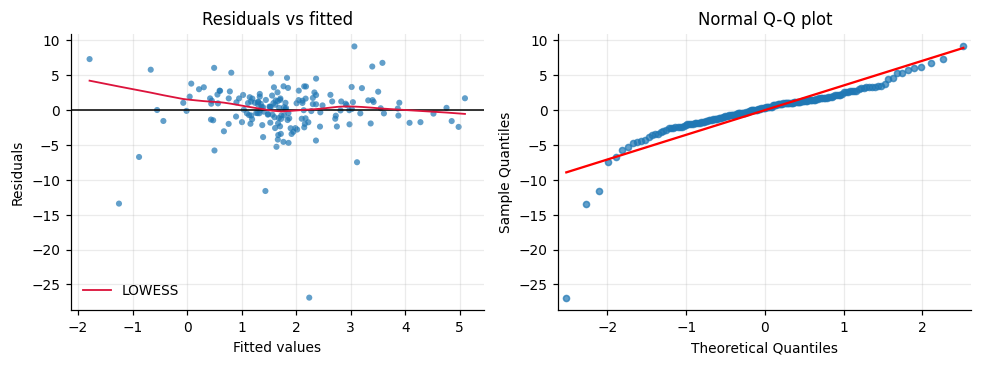

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].scatter(ols.fittedvalues, ols.resid, s=16, alpha=0.7, edgecolor="none")
axes[0].axhline(0, lw=1, color="black")
lo = sm.nonparametric.lowess(ols.resid, ols.fittedvalues, frac=0.6)
axes[0].plot(lo[:, 0], lo[:, 1], lw=1.2, color="crimson", label="LOWESS")
axes[0].set(xlabel="Fitted values", ylabel="Residuals",
            title="Residuals vs fitted")
axes[0].legend(frameon=False)
sm.qqplot(ols.resid, line="s", ax=axes[1], markersize=4, alpha=0.7)
axes[1].set_title("Normal Q-Q plot")
fig.tight_layout()

## Section C — Robustness checks

Three checks, each targeting a different concern: HC1 standard errors in case
the heteroskedasticity tests lack power, feasible WLS to exploit any error
variance structure, and a trimmed subsample to gauge how much the fit depends
on a few extreme contractions.

In [8]:
robust = smf.ols(FORMULA, data=df).fit(cov_type="HC1")

# feasible WLS: weight by the inverse of the fitted error variance
log_e2 = np.log(ols.resid ** 2)
aux = smf.ols("log_e2 ~ " + " + ".join(XS), data=df.assign(log_e2=log_e2)).fit()
wls = smf.wls(FORMULA, data=df, weights=1 / np.exp(aux.fittedvalues)).fit()

# trimmed: drop |studentised residual| > 3
student = pd.Series(ols.get_influence().resid_studentized_external, index=df.index)
dropped = df.loc[student.abs() > 3, ["country", Y]]
trimmed = smf.ols(FORMULA, data=df.loc[student.abs() <= 3]).fit(cov_type="HC1")

print("Dropped from the trimmed sample:")
print(dropped.to_string(index=False))

Dropped from the trimmed sample:
           country   growth24
West Bank and Gaza -24.656790
             Sudan -14.657023
       Timor-Leste -10.161913


In [9]:
def col(res, label):
    return pd.DataFrame({f"{label}: coef": res.params.round(4),
                         f"{label}: se": res.bse.round(4),
                         f"{label}: p": res.pvalues.round(4)})

comparison = pd.concat([col(ols, "OLS"), col(robust, "Robust"),
                        col(wls, "WLS"), col(trimmed, "Trimmed")], axis=1)
comparison

,OLS: coef,OLS: se,OLS: p,Robust: coef,Robust: se,Robust: p,WLS: coef,WLS: se,WLS: p,Trimmed: coef,Trimmed: se,Trimmed: p
Intercept,-2.7858,2.7809,0.3179,-2.7858,2.8349,0.3258,-2.9346,2.6591,0.2713,0.2979,1.9569,0.8790
lngdppc23,0.1889,0.3347,0.5732,0.1889,0.2877,0.5115,0.1659,0.3215,0.6064,-0.0530,0.2363,0.8225
gcf23,0.1401,0.0347,0.0001,0.1401,0.0436,0.0013,0.1541,0.0332,0.0000,0.1115,0.0341,0.0011
highinc,-0.9383,0.9952,0.3471,-0.9383,0.8507,0.2700,-0.9202,1.0134,0.3652,-0.8511,0.7562,0.2603


In [10]:
pd.DataFrame({
    "Model": ["OLS", "Robust (HC1)", "WLS", "Trimmed"],
    "N": [int(m.nobs) for m in (ols, robust, wls, trimmed)],
    "R-squared": [round(m.rsquared, 4) for m in (ols, robust, wls, trimmed)],
    "Adj. R-squared": [round(m.rsquared_adj, 4) for m in (ols, robust, wls, trimmed)],
    "F / Wald": [round(m.fvalue, 3) for m in (ols, robust, wls, trimmed)],
    "p": [round(m.f_pvalue, 4) for m in (ols, robust, wls, trimmed)],
})

,Model,N,R-squared,Adj. R-squared,F / Wald,p
0,OLS,171,0.0949,0.0786,5.835,0.0008
1,Robust (HC1),171,0.0949,0.0786,4.640,0.0038
2,WLS,171,0.1239,0.1081,7.871,0.0001
3,Trimmed,168,0.1365,0.1207,7.409,0.0001


The investment coefficient survives every variant, keeping both its sign and
roughly its magnitude, so the one result the model does support is not an
artefact of the covariance assumption or of a few outliers. The convergence
term stays insignificant throughout and even flips sign once the largest
contractions are trimmed, which is a reminder of how little a single-year
cross-section can say about convergence.